<a href="https://colab.research.google.com/github/jiritkhanpranali-cmyk/Sonar_Model1/blob/main/Sonar_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

In [ ]:
!pip install xgboost -q

In [ ]:
import pandas as pd

df = pd.read_csv('/content/sonar data (1).csv')

In [ ]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(207, 61)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float

,0
0.0200,0
0.0371,0
0.0428,0
0.0207,0
0.0954,0
...,...
0.0180,0
0.0084,0
0.0090,0
0.0032,0


In [ ]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]


In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(np.unique(y))

[0 1]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "Support Vector Machine":
        SVC(kernel='rbf', probability=True),

    "XGBoost":
        XGBClassifier(
            eval_metric='logloss',
            random_state=42
        )
}

In [ ]:
results = {}

best_accuracy = 0

best_model = None

best_model_name = ""

In [ ]:
for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    results[name] = accuracy

    print("="*50)

    print(name)

    print("Accuracy:", round(accuracy*100,2),"%")

    print(classification_report(y_test,prediction))

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

        best_model_name = name

Logistic Regression
Accuracy: 76.19 %
              precision    recall  f1-score   support

           0       0.71      0.96      0.81        23
           1       0.91      0.53      0.67        19

    accuracy                           0.76        42
   macro avg       0.81      0.74      0.74        42
weighted avg       0.80      0.76      0.75        42

KNN
Accuracy: 76.19 %
              precision    recall  f1-score   support

           0       0.74      0.87      0.80        23
           1       0.80      0.63      0.71        19

    accuracy                           0.76        42
   macro avg       0.77      0.75      0.75        42
weighted avg       0.77      0.76      0.76        42

Decision Tree
Accuracy: 76.19 %
              precision    recall  f1-score   support

           0       0.74      0.87      0.80        23
           1       0.80      0.63      0.71        19

    accuracy                           0.76        42
   macro avg       0.77      0.75   

In [ ]:
accuracy_df = pd.DataFrame({

    "Model":results.keys(),

    "Accuracy":results.values()

})

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_df

,Model,Accuracy
5,XGBoost,0.857143
3,Random Forest,0.857143
4,Support Vector Machine,0.809524
0,Logistic Regression,0.761905
1,KNN,0.761905
2,Decision Tree,0.761905


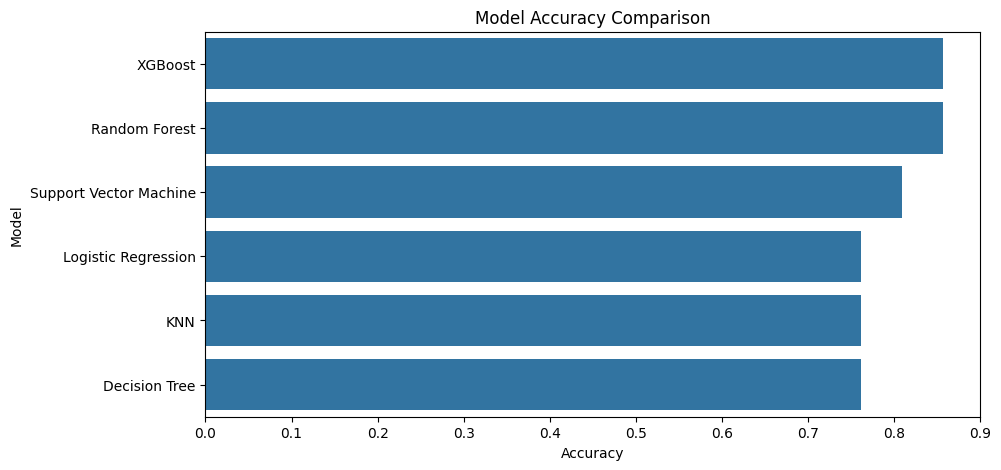

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=accuracy_df
)

plt.title("Model Accuracy Comparison")

plt.show()

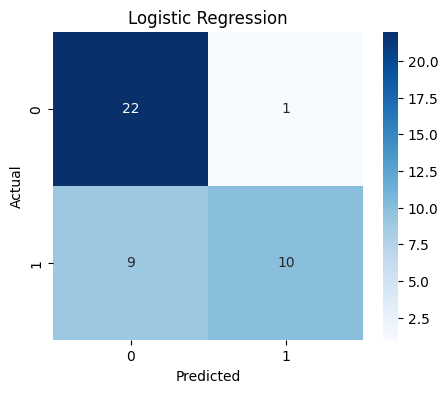

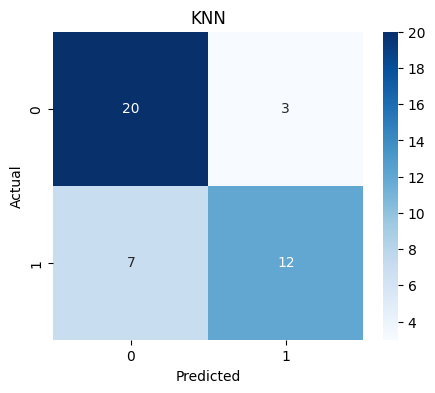

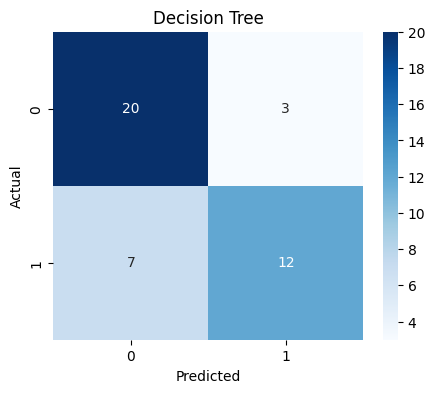

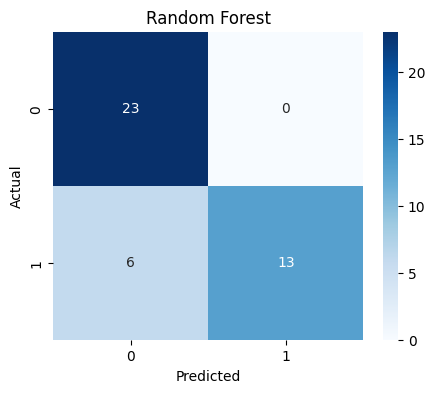

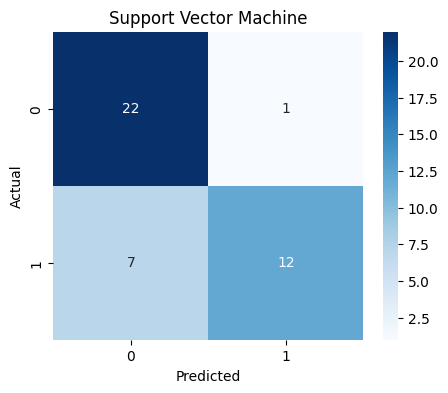

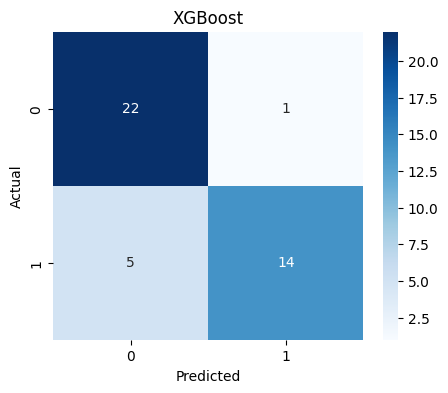

In [ ]:
for name, model in models.items():

    prediction = model.predict(X_test)

    cm = confusion_matrix(y_test,prediction)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

In [ ]:
print("Best Model :",best_model_name)

print("Accuracy :",round(best_accuracy*100,2),"%")

Best Model : Random Forest
Accuracy : 85.71 %


In [ ]:
joblib.dump(best_model,"best_sonar_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("best_sonar_model.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import os

if os.path.exists('best_sonar_model.pkl') and os.path.exists('scaler.pkl'):
    print("Both 'best_sonar_model.pkl' and 'scaler.pkl' files are present in the current directory.")
else:
    print("One or both of the '.pkl' files are missing. Please ensure they were downloaded correctly.")

Both 'best_sonar_model.pkl' and 'scaler.pkl' files are present in the current directory.


In [ ]:
%%writefile app.py

import joblib
import numpy as np
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained model and scaler
best_model = joblib.load('best_sonar_model.pkl')
scaler = joblib.load('scaler.pkl')

@app.route('/')
def home():
    return "Welcome to the Sonar Classification API!"

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get data from POST request
        data = request.get_json(force=True)
        features = np.array(data['features']).reshape(1, -1)

        # Scale the features
        scaled_features = scaler.transform(features)

        # Make prediction
        prediction = best_model.predict(scaled_features)

        # Inverse transform the prediction if LabelEncoder was used for output
        # In this case, y was encoded to 0 and 1, so we can map it back.
        # Assuming 0 is 'M' and 1 is 'R' based on previous outputs like np.unique(y)
        prediction_label = 'R' if prediction[0] == 1 else 'M'

        return jsonify({'prediction': prediction_label})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

Writing app.py


This code creates a simple Flask API for your model. Here's what it does:

1.  **Loads Model and Scaler**: It loads the `best_sonar_model.pkl` and `scaler.pkl` files.
2.  **`/` Route**: A basic route that returns a welcome message.
3.  **`/predict` Route**: This route accepts POST requests with JSON data. It expects a `features` key containing a list of numerical values representing the input features. It then scales these features using the loaded scaler, makes a prediction using the loaded model, and returns the predicted label ('R' or 'M') as a JSON response.
4.  **Error Handling**: Includes a basic error handler for invalid requests.

To run this application, you would typically execute it in a terminal. In a Colab environment, you'd usually install `flask` and then run it, often in a background process if you want to continue using the notebook.


In [ ]:
%%writefile requirements.txt
flask
numpy
scikit-learn
joblib
xgboost

Writing requirements.txt


In [ ]:
!pip install -r requirements.txt

## Pushing to GitHub

First, let's ensure Git is installed (it usually is in Colab, but it doesn't hurt to run this) and configure your user details.

### Authenticating with GitHub using a Personal Access Token (PAT)

To push to GitHub from Colab, you'll need to authenticate. The most secure way is to use a Personal Access Token (PAT).

**Steps to create a PAT:**
1. Go to your GitHub settings: `Settings > Developer settings > Personal access tokens > Tokens (classic) > Generate new token`.
2. Give your token a descriptive name (e.g., "Colab Access").
3. Select the necessary scopes. For pushing code, you'll typically need `repo` (full control of private repositories) and possibly `workflow` if you have GitHub Actions.
4. Copy the generated token immediately. You won't be able to see it again.

**Storing your PAT in Colab Secrets:**
To keep your PAT secure, store it in Colab's Secrets manager. Click the "🔑" icon on the left panel, click "Add new secret", and set the name as `GITHUB_TOKEN` and the value as your PAT.

Once stored, you can access it like this:

### Initialize a Git repository, add files, and commit

Now, let's initialize a Git repository in your current working directory (usually `/content/` in Colab), add all relevant files, and make an initial commit. You can adjust which files to add (e.g., `*.py`, `*.ipynb`, `*.pkl`) as needed. For simplicity, we'll add all files generated so far.

In [ ]:
# Initialize a Git repository in the current directory
!git init

# Add files to the staging area. You might want to be more selective here.
# For example, to add all .py, .ipynb, and .pkl files:
# !git add *.py *.ipynb *.pkl
# Or to add all changes:
!git add .

# Commit the changes
!git commit -m "Initial commit: Sonar Classification Project"
print('Git repository initialized and changes committed.')

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
[master (root-commit) d7237a5] Initial commit: Sonar Classification Project
 26 files changed, 51312 insertions(+)
 create mode 100644 .config/.last_opt_in_prompt.yaml
 create mode 100644 .config/.last_survey_prompt.yaml
 create mode 100644 .config/.last_update_check.json
 create mode 100644 .config/active_config
 create mode 100644 .config/config_sentinel
 create mode 100644 .config/configurations/config_default
 create mode 100644 .config/default_configs.db


In [ ]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir())

['.config', 'best_sonar_model.pkl', 'scaler.pkl', 'requirements.txt', 'sonar data (1).csv', '.git', 'app.py', 'sample_data']


In [ ]:
!ls -lh scaler.pkl

-rw-r--r-- 1 root root 2.8K Jul  8 08:36 scaler.pkl


In [ ]:
from google.colab import files
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Link to a Remote GitHub Repository and Push

Finally, you need to link your local repository to a remote repository on GitHub and push your changes.

**Steps to create a new GitHub repository:**
1. Go to [GitHub](https://github.com/).
2. Click the "+" icon in the top right corner and select "New repository".
3. Give it a name (e.g., `sonar-classification`).
4. Choose public or private.
5. **DO NOT** initialize with a README, .gitignore, or license, as you already have files.
6. Click "Create repository".
7. On the next page, copy the URL for the remote repository (e.g., `https://github.com/your-username/sonar-classification.git`).

Now, replace the placeholder URL below with your actual repository URL and run the cell to push your code.